In [1]:
import pypsa
import geopandas as gpd

# Load the shapefile using GeoPandas
lines_gdf = gpd.read_file("qgis/lines_aut.shp")

# Create a new PyPSA network
network = pypsa.Network()

# Add lines to the network from the shapefile
for _, line in lines_gdf.iterrows():
    network.add("Line",
                f"Line_{line['id']}",  # Assuming 'id' is a unique identifier for each line
                bus0=line['bus0'],    # Replace with the actual column name for the starting bus
                bus1=line['bus1'],    # Replace with the actual column name for the ending bus
                length=line['length'] # Replace with the actual column name for line length
                )

print(network)

KeyError: 'bus0'

In [10]:
lines_gdf

,id,name,active,length,i_max,v_ref,r,x,c,comm,decomm,scenario,from_node,to_node,s_max,type,references,geometry
0,14001.0,182/1,1,5.360,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (377942.108 480212.213, 377943.906 ..."
1,14002.0,182/2,1,5.340,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (381270.464 484013.966, 381233.822 ..."
2,14003.0,182/7,1,6.220,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14003.0,14001.0,89.547027,None,None,"LINESTRING (378019.552 480229.434, 378092.088 ..."
3,14004.0,184/1,1,5.830,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14002.0,89.547027,None,None,"LINESTRING (381223.187 484087.493, 381158.659 ..."
4,11030.0,127-9,1,16.189,470.0,110.0,0.2024,0.4329,6.0483,2024-01-01,2365/01/01,BGL,11002.0,11005.0,89.500000,None,None,"LINESTRING (666823.42 444499.182, 666780.956 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,20600.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20006.0,90000.0,0.000000,None,None,None
2032,20601.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20003.0,90000.0,0.000000,None,None,None
2033,20602.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20002.0,90000.0,0.000000,None,None,None
2034,31042.0,None,1,0.100,0.0,380.0,0.0000,0.0000,0.0000,2024-01-01,2100/01/01,BGL,31027.0,31020.0,0.000000,None,None,"LINESTRING (622695.568 376588.232, 622645.564 ..."


In [11]:
import pypsa
import geopandas as gpd

# Load the shapefile using GeoPandas
lines_gdf = gpd.read_file("qgis/lines_aut.shp")

# Create a new PyPSA network
network = pypsa.Network()

# Add lines to the network from the shapefile
for _, line in lines_gdf.iterrows():
    network.add("Line",
                f"Line_{line['id']}",  # 'id' is the unique identifier for each line
                bus0=f"Bus_{line['from_node']}",  # 'from_node' is the starting bus
                bus1=f"Bus_{line['to_node']}",    # 'to_node' is the ending bus
                length=line['length'],           # 'length' is the line length
                r=line['r'],                     # 'r' is the resistance
                x=line['x'],                     # 'x' is the reactance
                s_nom=line['s_max']              # 's_max' is the nominal power
                )

print(network)

Index(['Line_14001.0'], dtype='object')
Index(['Line_14001.0'], dtype='object')
Index(['Line_14002.0'], dtype='object')
Index(['Line_14002.0'], dtype='object')
Index(['Line_14003.0'], dtype='object')
Index(['Line_14003.0'], dtype='object')
Index(['Line_14004.0'], dtype='object')
Index(['Line_14004.0'], dtype='object')
Index(['Line_11030.0'], dtype='object')
Index(['Line_11030.0'], dtype='object')
Index(['Line_11041.0'], dtype='object')
Index(['Line_11041.0'], dtype='object')
Index(['Line_11042.0'], dtype='object')
Index(['Line_11042.0'], dtype='object')
Index(['Line_11025.0'], dtype='object')
Index(['Line_11025.0'], dtype='object')
Index(['Line_14005.0'], dtype='object')
Index(['Line_14005.0'], dtype='object')
Index(['Line_14118.0'], dtype='object')
Index(['Line_14118.0'], dtype='object')
Index(['Line_11032.0'], dtype='object')
Index(['Line_11032.0'], dtype='object')
Index(['Line_10025.0'], dtype='object')
Index(['Line_10025.0'], dtype='object')
Index(['Line_10026.0'], dtype='object')


Unnamed PyPSA Network


In [13]:
network.plot()

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/pypsa/plot.py:206: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  zip(*compute_bbox_with_margins(margin, x[buses], y[buses])), ()


ValueError: zero-size array to reduction operation fmin which has no identity

In [14]:
import pypsa
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import pandas as pd


In [15]:
# Load the shapefile into a GeoDataFrame
shapefile_path = "qgis/lines_aut.shp"
lines_aut = gpd.read_file(shapefile_path)

# Check the first few rows to understand the structure
print(lines_aut.head())


        id   name  active  length   i_max  v_ref       r       x       c  \
0  14001.0  182/1       1   5.360  1077.0  110.0  0.0557  0.3824  0.0000   
1  14002.0  182/2       1   5.340  1077.0  110.0  0.0557  0.3824  0.0000   
2  14003.0  182/7       1   6.220   470.0  110.0  0.1690  0.4035  0.0000   
3  14004.0  184/1       1   5.830   470.0  110.0  0.1690  0.4035  0.0000   
4  11030.0  127-9       1  16.189   470.0  110.0  0.2024  0.4329  6.0483   

        comm      decomm scenario  from_node  to_node       s_max  type  \
0 2024-01-01  2100/01/01      AUT    14001.0  14003.0  205.196059  None   
1 2024-01-01  2100/01/01      AUT    14001.0  14003.0  205.196059  None   
2 2024-01-01  2100/01/01      AUT    14003.0  14001.0   89.547027  None   
3 2024-01-01  2100/01/01      AUT    14001.0  14002.0   89.547027  None   
4 2024-01-01  2365/01/01      BGL    11002.0  11005.0   89.500000  None   

  references                                           geometry  
0       None  LINESTRING (

In [16]:
# Check if there are any useful attributes, such as voltage or capacity
print(lines_aut.columns)

# Extract the geometries (the lines)
lines_geometry = lines_aut.geometry

# Let's inspect the geometry of the first line
print(lines_geometry.iloc[0])


Index(['id', 'name', 'active', 'length', 'i_max', 'v_ref', 'r', 'x', 'c',
       'comm', 'decomm', 'scenario', 'from_node', 'to_node', 's_max', 'type',
       'references', 'geometry'],
      dtype='object')
LINESTRING (377942.1076980555 480212.21295696654, 377943.9056279718 480127.741595645, 378083.366653342 480167.9575830929, 378321.86868655705 480331.9170768452, 378564.03632272873 480498.41840223887, 378809.8763110549 480667.450881975, 379049.6774318768 480832.34732443583, 379299.15254464315 481003.9108651144, 379555.50769762375 481180.21848813386, 379657.8581482204 481423.34104389464, 379773.09048893495 481697.0908324816, 379923.7573868675 481934.6777041802, 380095.35800845514 482205.30106073193, 380267.5399429111 482476.87263551075, 380438.6977349648 482746.8300327683, 380596.46174698585 482995.6831801499, 380768.68615612795 483267.37022968795, 380923.4286811337 483511.484924676, 381091.9411593523 483763.82119120396, 381233.8223150056 484001.20282049244, 381248.53270367975 484056.

In [17]:
# Create an empty PyPSA network
network = pypsa.Network()

# Define a function to create buses from coordinates
def add_buses_from_line(line, network):
    # Extract the coordinates of the start and end points
    start, end = line.coords[0], line.coords[-1]
    
    # Create buses at the start and end coordinates
    start_bus_id = f"Bus_{start}"
    end_bus_id = f"Bus_{end}"
    
    # Add the buses to the network
    network.add("Bus", start_bus_id, x=start[0], y=start[1])
    network.add("Bus", end_bus_id, x=end[0], y=end[1])
    
    return start_bus_id, end_bus_id

# Test the bus addition by adding buses for the first transmission line
start_bus, end_bus = add_buses_from_line(lines_geometry.iloc[0], network)

print(f"Added buses: {start_bus}, {end_bus}")


Added buses: Bus_(377942.1076980555, 480212.21295696654), Bus_(381248.53270367975, 484056.3602990818)


In [18]:
# Define a function to add lines
def add_lines_from_shapefile(network, shapefile):
    for idx, row in shapefile.iterrows():
        line = row['geometry']
        
        # Add buses for this line
        start_bus, end_bus = add_buses_from_line(line, network)
        
        # Add the line to the network
        network.add("Line", f"Line_{idx}", bus0=start_bus, bus1=end_bus, x=0, y=0, r=0.01, s_nom=100, capital_cost=500)
        
    print(f"Successfully added {len(shapefile)} lines to the network")

# Add lines to the network
add_lines_from_shapefile(network, lines_aut)

# Check if the lines have been added to the network
print(f"Lines in network: {len(network.lines)}")


AttributeError: 'NoneType' object has no attribute 'coords'

In [19]:
# Check the geometries and see if there are any None values
print(lines_aut['geometry'].head())

# Check for any None geometries in the shapefile
invalid_geometries = lines_aut[lines_aut['geometry'].isnull()]
print(f"Rows with invalid geometries: {invalid_geometries}")


0    LINESTRING (377942.108 480212.213, 377943.906 ...
1    LINESTRING (381270.464 484013.966, 381233.822 ...
2    LINESTRING (378019.552 480229.434, 378092.088 ...
3    LINESTRING (381223.187 484087.493, 381158.659 ...
4    LINESTRING (666823.42 444499.182, 666780.956 4...
Name: geometry, dtype: geometry
Rows with invalid geometries:            id  name  active  length  i_max  v_ref             r             x  \
11    10025.0  None       0     1.0    0.0  110.0      4.289418     16.103493   
12    10026.0  None       1     1.0    0.0  110.0      3.288038     11.749295   
25    10073.0  None       1     1.0    0.0  110.0      2.111092      8.294320   
47    10294.0  None       1     1.0    0.0  110.0      3.103782      4.954818   
52    10027.0  None       0     1.0    0.0  110.0      1.276756      4.562290   
...       ...   ...     ...     ...    ...    ...           ...           ...   
2029  20598.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   
2030  20599.0  

In [20]:
# Filter out rows with invalid geometries
lines_aut_cleaned = lines_aut.dropna(subset=['geometry'])

# Check the cleaned shapefile
print(lines_aut_cleaned['geometry'].head())


0    LINESTRING (377942.108 480212.213, 377943.906 ...
1    LINESTRING (381270.464 484013.966, 381233.822 ...
2    LINESTRING (378019.552 480229.434, 378092.088 ...
3    LINESTRING (381223.187 484087.493, 381158.659 ...
4    LINESTRING (666823.42 444499.182, 666780.956 4...
Name: geometry, dtype: geometry


In [22]:
# Create an empty PyPSA network
network = pypsa.Network()

# Define a function to create buses from coordinates
def add_buses_from_line(line, network):
    # Extract the coordinates of the start and end points
    start, end = line.coords[0], line.coords[-1]
    
    # Create buses at the start and end coordinates
    start_bus_id = f"Bus_{start}"
    end_bus_id = f"Bus_{end}"
    
    # Add the buses to the network
    network.add("Bus", start_bus_id, x=start[0], y=start[1])
    network.add("Bus", end_bus_id, x=end[0], y=end[1])
    
    return start_bus_id, end_bus_id

# Test the bus addition by adding buses for the first transmission line
start_bus, end_bus = add_buses_from_line(lines_geometry.iloc[0], network)

print(f"Added buses: {start_bus}, {end_bus}")


Added buses: Bus_(377942.1076980555, 480212.21295696654), Bus_(381248.53270367975, 484056.3602990818)


In [24]:
def add_lines_from_shapefile(network, shapefile):
    for idx, row in shapefile.iterrows():
        line = row['geometry']
        
        if line is None:
            print(f"Skipping line {idx} due to invalid geometry.")
            continue  # Skip invalid geometries
        
        # Add buses for this line
        start_bus, end_bus = add_buses_from_line(line, network)
        
        # Check if the buses were added correctly
        if start_bus is None or end_bus is None:
            print(f"Skipping line {idx} due to invalid bus creation.")
            continue  # Skip if buses weren't created
        
        # Add the line to the network
        network.add("Line", f"Line_{idx}", bus0=start_bus, bus1=end_bus, x=0, y=0, r=0.01, s_nom=100, capital_cost=500)
    
    print(f"Successfully added {len(shapefile)} lines to the network")

# Add lines to the network
add_lines_from_shapefile(network, lines_aut)

# Check if the lines have been added to the network
print(f"Lines in network: {len(network.lines)}")


Skipping line 11 due to invalid geometry.
Skipping line 12 due to invalid geometry.
Skipping line 25 due to invalid geometry.


Skipping line 47 due to invalid geometry.
Skipping line 52 due to invalid geometry.
Skipping line 53 due to invalid geometry.
Skipping line 54 due to invalid geometry.
Skipping line 55 due to invalid geometry.
Skipping line 56 due to invalid geometry.
Skipping line 57 due to invalid geometry.
Skipping line 58 due to invalid geometry.
Skipping line 59 due to invalid geometry.
Skipping line 60 due to invalid geometry.
Skipping line 61 due to invalid geometry.
Skipping line 62 due to invalid geometry.
Skipping line 63 due to invalid geometry.
Skipping line 64 due to invalid geometry.
Skipping line 65 due to invalid geometry.
Skipping line 66 due to invalid geometry.
Skipping line 67 due to invalid geometry.
Skipping line 68 due to invalid geometry.
Skipping line 69 due to invalid geometry.
Skipping line 70 due to invalid geometry.
Skipping line 71 due to invalid geometry.
Skipping line 72 due to invalid geometry.
Skipping line 73 due to invalid geometry.
Skipping line 74 due to invalid ge

Skipping line 113 due to invalid geometry.
Skipping line 114 due to invalid geometry.
Skipping line 115 due to invalid geometry.
Skipping line 116 due to invalid geometry.
Skipping line 117 due to invalid geometry.
Skipping line 118 due to invalid geometry.
Skipping line 119 due to invalid geometry.
Skipping line 120 due to invalid geometry.
Skipping line 121 due to invalid geometry.
Skipping line 122 due to invalid geometry.
Skipping line 123 due to invalid geometry.
Skipping line 124 due to invalid geometry.
Skipping line 125 due to invalid geometry.
Skipping line 127 due to invalid geometry.


Skipping line 153 due to invalid geometry.
Skipping line 160 due to invalid geometry.


Skipping line 199 due to invalid geometry.
Skipping line 201 due to invalid geometry.


...

Skipping line 1660 due to invalid geometry.
Skipping line 1661 due to invalid geometry.
Skipping line 1666 due to invalid geometry.
Skipping line 1671 due to invalid geometry.
Skipping line 1676 due to invalid geometry.


Skipping line 1680 due to invalid geometry.
Skipping line 1689 due to invalid geometry.
Skipping line 1691 due to invalid geometry.
Skipping line 1692 due to invalid geometry.
Skipping line 1695 due to invalid geometry.
Skipping line 1696 due to invalid geometry.
Skipping line 1697 due to invalid geometry.


Skipping line 1702 due to invalid geometry.
Skipping line 1704 due to invalid geometry.
Skipping line 1705 due to invalid geometry.
Skipping line 1711 due to invalid geometry.
Skipping line 1712 due to invalid geometry.
Skipping line 1713 due to invalid geometry.
Skipping line 1714 due to invalid geometry.
Skipping line 1720 due to invalid geometry.


Skipping line 1724 due to invalid geometry.
Skipping line 1725 due to invalid geometry.
Skipping line 1726 due to invalid geometry.
Skipping line 1730 due to invalid geometry.
Skipping line 1731 due to invalid geometry.
Skipping line 1732 due to invalid geometry.
Skipping line 1733 due to invalid geometry.
Skipping line 1734 due to invalid geometry.
Skipping line 1737 due to invalid geometry.
Skipping line 1738 due to invalid geometry.
Skipping line 1739 due to invalid geometry.
Skipping line 1740 due to invalid geometry.
Skipping line 1745 due to invalid geometry.
Skipping line 1746 due to invalid geometry.
Skipping line 1747 due to invalid geometry.
Skipping line 1748 due to invalid geometry.
Skipping line 1749 due to invalid geometry.
Skipping line 1750 due to invalid geometry.
Skipping line 1751 due to invalid geometry.
Skipping line 1752 due to invalid geometry.
Skipping line 1756 due to invalid geometry.
Skipping line 1757 due to invalid geometry.


Skipping line 1761 due to invalid geometry.
Skipping line 1762 due to invalid geometry.
Skipping line 1763 due to invalid geometry.
Skipping line 1764 due to invalid geometry.
Skipping line 1765 due to invalid geometry.
Skipping line 1766 due to invalid geometry.
Skipping line 1767 due to invalid geometry.
Skipping line 1768 due to invalid geometry.
Skipping line 1769 due to invalid geometry.
Skipping line 1770 due to invalid geometry.
Skipping line 1771 due to invalid geometry.
Skipping line 1772 due to invalid geometry.
Skipping line 1773 due to invalid geometry.
Skipping line 1774 due to invalid geometry.
Skipping line 1775 due to invalid geometry.
Skipping line 1776 due to invalid geometry.
Skipping line 1777 due to invalid geometry.
Skipping line 1779 due to invalid geometry.
Skipping line 1780 due to invalid geometry.
Skipping line 1781 due to invalid geometry.
Skipping line 1782 due to invalid geometry.
Skipping line 1783 due to invalid geometry.
Skipping line 1784 due to invali

In [25]:
# Print the invalid geometries to understand more about the problem
invalid_geometries = lines_aut[lines_aut['geometry'].isnull()]
for idx, row in invalid_geometries.iterrows():
    print(f"Line {idx} - Geometry: {row['geometry']}")


Line 11 - Geometry: None
Line 12 - Geometry: None
Line 25 - Geometry: None
Line 47 - Geometry: None
Line 52 - Geometry: None
Line 53 - Geometry: None
Line 54 - Geometry: None
Line 55 - Geometry: None
Line 56 - Geometry: None
Line 57 - Geometry: None
Line 58 - Geometry: None
Line 59 - Geometry: None
Line 60 - Geometry: None
Line 61 - Geometry: None
Line 62 - Geometry: None
Line 63 - Geometry: None
Line 64 - Geometry: None
Line 65 - Geometry: None
Line 66 - Geometry: None
Line 67 - Geometry: None
Line 68 - Geometry: None
Line 69 - Geometry: None
Line 70 - Geometry: None
Line 71 - Geometry: None
Line 72 - Geometry: None
Line 73 - Geometry: None
Line 74 - Geometry: None
Line 75 - Geometry: None
Line 76 - Geometry: None
Line 77 - Geometry: None
Line 78 - Geometry: None
Line 79 - Geometry: None
Line 80 - Geometry: None
Line 81 - Geometry: None
Line 82 - Geometry: None
Line 83 - Geometry: None
Line 84 - Geometry: None
Line 85 - Geometry: None
Line 86 - Geometry: None
Line 87 - Geometry: None


In [26]:
# Check which geometries are invalid
invalid_lines = lines_aut[~lines_aut['geometry'].is_valid]
print(f"Invalid geometries: {invalid_lines}")


Invalid geometries:            id  name  active  length  i_max  v_ref             r             x  \
11    10025.0  None       0     1.0    0.0  110.0      4.289418     16.103493   
12    10026.0  None       1     1.0    0.0  110.0      3.288038     11.749295   
25    10073.0  None       1     1.0    0.0  110.0      2.111092      8.294320   
47    10294.0  None       1     1.0    0.0  110.0      3.103782      4.954818   
52    10027.0  None       0     1.0    0.0  110.0      1.276756      4.562290   
...       ...   ...     ...     ...    ...    ...           ...           ...   
2029  20598.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   
2030  20599.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   
2031  20600.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   
2032  20601.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   
2033  20602.0  None       1     1.0    0.0  220.0  48400.000000  48400.000000   

       

In [27]:
# Clean the invalid geometries using buffer(0)
lines_aut['geometry'] = lines_aut['geometry'].apply(lambda geom: geom.buffer(0) if not geom.is_valid else geom)

# Re-check if there are still invalid geometries
invalid_lines = lines_aut[~lines_aut['geometry'].is_valid]
print(f"Invalid geometries after cleaning: {invalid_lines}")


AttributeError: 'NoneType' object has no attribute 'is_valid'

In [28]:
# Remove invalid geometries
lines_aut_cleaned = lines_aut[lines_aut['geometry'].is_valid]

# Re-check
print(f"Remaining lines: {len(lines_aut_cleaned)}")


Remaining lines: 1434


In [29]:
# Print the problematic lines and their geometries
print(invalid_lines[['geometry']])


     geometry
11       None
12       None
25       None
47       None
52       None
...       ...
2029     None
2030     None
2031     None
2032     None
2033     None

[602 rows x 1 columns]


In [30]:
# Proceed with adding the lines to the network
add_lines_from_shapefile(network, lines_aut_cleaned)


Successfully added 1434 lines to the network


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


ValueError: Axis limits cannot be NaN or Inf

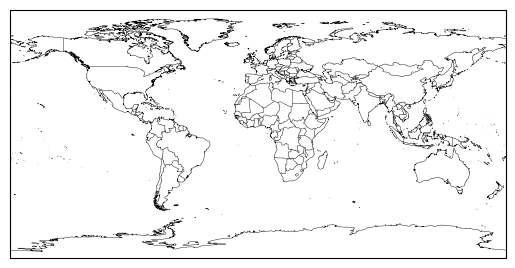

In [31]:
network.plot()

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


ValueError: Axis limits cannot be NaN or Inf

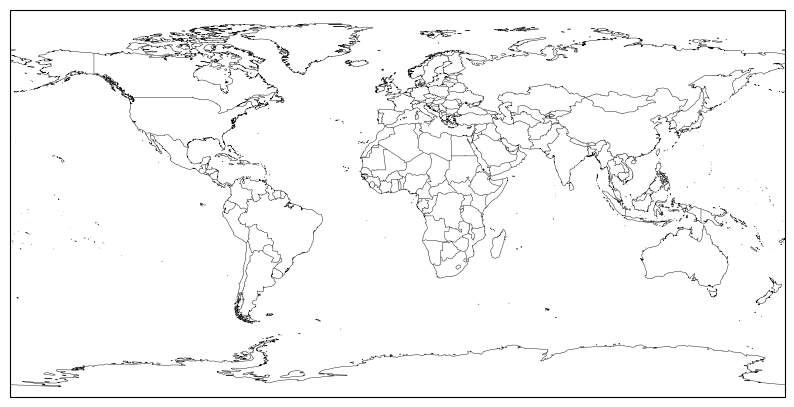

In [34]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Define the projection
projection = ccrs.PlateCarree()

# Create a figure with the specified projection
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': projection})

# Plot the network with the projection
network.plot(ax=ax)

# Set the extent to zoom in on Austria (Longitude: 9.5 to 17.0, Latitude: 46.0 to 49.0)
# Make sure to set the limits directly on the axis after plotting
ax.set_xlim([9.5, 17.0])  # Longitude bounds for Austria
ax.set_ylim([46.0, 49.0])  # Latitude bounds for Austria

# Optionally add a title and other elements
ax.set_title("PyPSA Network - Austria", fontsize=14)

# Show the plot
plt.show()
